#1- Drive Bağlantısı

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2- Veriyi Anlamak

Bu proje kapsamında kullanacağımız veri seti TrashNet isimli veri setidir. Stanford Üniversitesi öğrencileri tarafından hazırlanılmıştır.

Veri seti altı farklı sınıftan oluşmaktadır. Veri setinde Cam, Kağıt, Karton, Plastik, Metal ve Çöp olmak üzere toplamda 2527 adet görüntü
bulunmaktadır.

Görüntülerin dağılımı:
- 501 cam
- 594 kağıt
- 403 karton
- 482 plastik
- 410 metal
- 137 çöp

Görüntüler, beyaz bir panoya yerleştirilerek ve güneş ışığı veya oda aydınlatması kullanılarak çekilmiştir. Görüntüler, 512 x 384 piksel
boyutlarında ve 3 (RGB) kanallıdır.


# 2.1- Gerekli Kütüphanelerin Import Edilmesi

In [2]:
# pip install imutils

#Veriyi okuma ve işleme adımında kullanılacak olan kütüphaneler
import cv2
import urllib
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import random, os, glob
from imutils import paths
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from urllib.request import urlopen

#Warningleri kapatmak için kullanılmaktadır.
import warnings
warnings.filterwarnings('ignore')

# Model değerlendirme için kullanılacak olan kütüphaneler
from sklearn.metrics import confusion_matrix, classification_report

#Model için kullanılacak olan kütüphaneler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D, Dense, Dropout, SpatialDropout2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img

# 2.2- Veri Setinin Okunması

In [3]:
dir_path = "/content/drive/MyDrive/Garbage classification"

In [4]:
# Target size ve label etiket değerlerini belirleyelim

# Burada boyut bilgisini tutuyoruz çünkü normalde 512x384 olan boyutu 224x224'e dönüştüreceğiz. CNN'deki havuzlama katmanı aslında. Görüntünün özelliğini kaybetmeden boyutunu küçültme işlemi ...
# ... Yapmamızdaki sebep: hesaplama karmaşıklığını azaltnak , eğitim sürecini azaltmak , daha fazla görsel kullanabilmek
target_size = (224,224)

# Normalde veri setinin etiketleri yok. Biz etiketleyeceğiz klasör isimlerinden
waste_labels = {
    'cardboard': 0,
    'glass': 1,
    'metal': 2,
    'paper': 3,
    'plastic': 4,
    'trash': 5
}

In [5]:
def load_dataset(path):
  """
  Görsellerin bulunduğu dizindeki görüntüyü okuyup etiket oluşturan fonksiyon.

  Return:
    x: görüntülere ait matris görüntüleri
    labels: görüntülere ait etiketler (sınıf bilgileri)

  """


  x = []
  labels = []

  # Gönderdiğimiz path'deki görüntüleri listeleyip sıralayacak
  image_paths = sorted(list(paths.list_images(path)))

  for image_path in image_paths:
    # Belirtilen path'teki görüntüler OpenCV kütüphanesi ike okunacak
    img = cv2.imread(image_path)

    # Okunan görüntüler başlangıçta belirttiğimiz target_size'a göre yeniden ölçeklenecek
    img = cv2.resize(img , target_size)

    # Ölçeklendirilen görüntüler x listesine ekleyelim başta oluşturduğumuz
    x.append(img)

    # Her bir path '/' ifadesi ile ayrıldığında dönen listenin sondan ikinci elemanı label'ı temsil edecek
    label = image_path.split(os.path.sep)[-2]

    # Yakalanan label'ların sayısal karşılıklarının olduğu waste_labels sözlüğü içerisinden gönderilen key  değerine karşılık gelen value'yu alarak label oluşturacağız
    labels.append(waste_labels[label])


  # Veri setini random şekilde karıştıralım çünkü şu an klasörlerle ayrılmış şekilde duruyor hepsi
  x , labels = shuffle(x , labels , random_state=42)

  # Boyut ve sınıf bilgisini gösterelim
  print(f"X Boyutu: {np.array(x).shape}")
  print(f"Label sınıf sayısı {len(np.unique(labels))} Gözlem sayısı: {len(labels)}")

  return x , labels

In [6]:
# Fonksiyonumuzu çalıştıralım
x,labels = load_dataset(dir_path)

X Boyutu: (2527, 224, 224, 3)
Label sınıf sayısı 6 Gözlem sayısı: 2527


In [7]:
# Daha sonra kullanacağımız için bu return edilen boyut bilgilerini saklayalım
input_shape = (np.array(x[0]).shape[1] , np.array(x[0]).shape[1] , 3)
print(input_shape)

(224, 224, 3)


# 2.3- Veri Setinden Örnekler Gösterilmesi

In [8]:
def visualize_img(image_batch , label_batch):
  """
  Parametreler:
    image_batch: görüntülere ait matris bilgilerini tutar
    labek_batch: görüntünün ait olduğu sınıf bilgisini tutan liste
  """

  plt.figure(figsize=(10,10))
  for n in range(10):
    ax = plt.subplot(5 , 5 , n+1)
    plt.imshow(image_batch[n])
    plt.title(np.array(list(waste_labels.keys())) [to_categorical(labels , num_classes=6) [n]==1] [0].title())
    plt.axis("off")

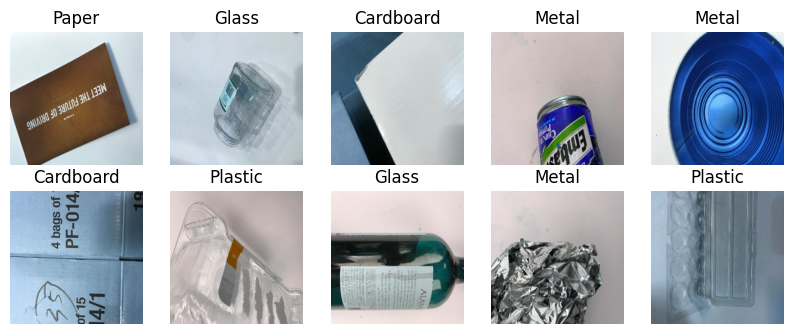

In [9]:
visualize_img(x , labels)

# 3- Veriyi Hazırlamak

Klasik ön işlemeye ek olarak görüntülere gerçek dünya özelliği ekleme (Data Augmentation) işlemi gerçekleştireceğiz.

Bizim verilerimiz beyaz pano altında çekilmiş olduğundan bahsetmiştik. Ama katı atıklar normalde bu şekilde beyaz pano altında olmayacağından dolayı bu görüntüleri gerçek hayata yakın özelliklerle çeşitlendirmemiz gerekiyor.

Data Augmentation, modeli küçük varyasyonlara kadar daha sağlam (robust) hale getirir. Dolayısıyla modelin overfitting yapmasının önüne geçer.
<br></br>

Attribute değerlendirmesi:
- horizontal_flip=True ->
  Görselleri yatay eksende rastgele çevirir.
  Örneğin, bir insan yüzü sağa bakıyorsa, solda bakan bir versiyonu da oluşturulabilir.

- vertical_flip=True ->
Görselleri dikey eksende rastgele çevirir.
Örneğin, yukarıya bakan bir ok aşağıya bakan hale getirilebilir.
Genellikle simetrik olmayan verilerde dikkatli kullanılmalıdır (örneğin, yazılar için önerilmez).

- validation_split=0.1 ->
Veri setinin %10’unu doğrulama (validation) için ayırır.
Modelin eğitimi sırasında ayrı bir doğrulama kümesi kullanılmasını sağlar.

- rescale=1./255 ->
Piksel değerlerini [0, 255] aralığından [0,1] aralığına ölçeklendirir.
Modelin daha iyi öğrenebilmesi için normalizasyon yapar.

- shear_range=0.1 ->
Görsellerde rastgele "kesme" (shearing) işlemi uygular.
Örneğin, bir kareyi paralel kenara dönüştürme gibi geometrik bozulmalar yapar. Yani görüntüye saat yönü tersine eğim, esneme verir.

- zoom_range=0.1 ->
Görselleri rastgele yakınlaştırır veya uzaklaştırır.
%10 oranında zoom ekler.

- width_shift_range=0.1 ->
Görselleri yatay eksende %10 oranında rastgele kaydırır.
Örneğin, bir nesne biraz sola veya sağa kaydırılabilir.

- height_shift_range=0.1 ->
Görselleri dikey eksende %10 oranında rastgele kaydırır.
Örneğin, bir nesne yukarı veya aşağı kaydırılabilir.




In [10]:
# Train veri seti için bir generator tanımlıyoruz
# Bu generator'ın görevi, veri üretmektir. Gerçek zamanlı veri çeşitlendirme yapacak. Küçük bir görüntü kümesinden zengin, çeşitli bir görüntü kümesi oluşturma imkanı verecek ...
# ... Bunu da kırpma , çevirme , doldurma , görüntü ekleme gibi teknikleri kullanarak sağlar. Böylece veri miktarı artırılmış olur.
train = ImageDataGenerator(horizontal_flip=True , vertical_flip=True , validation_split=0.1 , rescale=1./255 , shear_range=0.1 , zoom_range=0.1 , width_shift_range=0.1 , height_shift_range=0.1)

# Test veri seti için bir generator tanımlıyoruz
test = ImageDataGenerator(rescale=1/255 , validation_split=0.1)

In [11]:
# Generator'ı üstte tanımladıktan sonra "flow_from_directory" fonksiyonu kullanarak kendi veri setimiz üzerinde ImageDataGenerator nesnesini kullanacağız.
#  flow_from_directory fonksiyonu, TensorFlow ortamına görüntüleri okumak için kullanılan bir yöntemdir.
# Attribute açıklama:
  # directory=dir_path -> resimlerimizin olduğu dizin
  # target_size=(target_size) -> bulunan görsellerin boyutlarını ölçeklendirdik
  # class_mode="categorical" -> ilgilenilen kategorik değişkenin sınıfını ifade eder. İkiden fazla sınıflandırma işlemi yaptığımız için "categorical" yaptık. İkili yapsaydık "binary" yazardık
  # subset="training" -> ImageDataGenerator kısmında validation_split kullandığımız için verinin alt kümesinin bu şekilde belirtme yapılması gerekiyor

train_generator = train.flow_from_directory(directory=dir_path , target_size=(target_size) , class_mode="categorical" , subset="training")

test_generator = test.flow_from_directory(directory=dir_path , target_size=(target_size) , class_mode="categorical" , subset="validation")

Found 2276 images belonging to 6 classes.
Found 251 images belonging to 6 classes.


# 4- Modelleme

# 4.1 Sıfırdan CNN Modeli Kurma
- Sequential
- Evrişim Katmanı
- Havuzlama Katmanı
- Aktivasyon Fonks. Katmanı
- Flatting Katmanı
- Dense Katmanı
- Dropout Katmanı

In [12]:
# Birinci basamağımız
# Sinir ağı kurma yöntemimiz. Bu şekilde sıralı katmanlardan oluşan bir sinir ağı oluşturacağız
model = Sequential()

In [13]:
# Modelimize "Evrişim Katmanı" ekleyelim
# Bu katmanda giriş görüntüsü üzerinden öznitelik çıkarımı yapıyorduk.
# Attributelar:
  # filters=32 -> filtre sayımız
  # kernel_size=(3,3) -> filtrenin boyutu
  # padding="same" -> giriş matrisiyle çıkış matrisinin aynı boyutta olması
model.add(Conv2D(filters=32 , kernel_size=(3,3) , padding="same" , input_shape=(input_shape) , activation="relu"))  # kernel_size -> filtrenin boyutu

In [14]:
# Modelimize "Havuzlama Katmanı" ekleyelim. Biz burada max pooling'i kullandık. Avarege pooling de kullanabilirdik
# Bu katmanda öznitelikleri kaybetmeden görüntünün küçültülmesini sağlıyorduk.
# Attributelar:
  # pool_size=2 -> filtrenin boyut bilgisi. Evrişim katmanında yaşanacak olan performans kaybının önüne geöçmek için kullanıyoruz.
  # strides=(2,2) ->
model.add(MaxPooling2D(pool_size=2 , strides=(2,2)))

In [15]:
model.add(Conv2D(filters=64 , kernel_size=(3,3) , padding="same" , input_shape=(input_shape) , activation="relu"))  # kernel_size -> filtrenin boyutu
model.add(MaxPooling2D(pool_size=2 , strides=(2,2)))

In [16]:
model.add(Conv2D(filters=32 , kernel_size=(3,3) , padding="same" , input_shape=(input_shape) , activation="relu"))  # kernel_size -> filtrenin boyutu
model.add(MaxPooling2D(pool_size=2 , strides=(2,2)))

In [17]:
# Flatten Katmanımızı Ekleyelim
  # Bu düzleştirme işleminden sonra artık nöronlarla ilgileneceğiz
model.add(Flatten())

In [18]:
# Dense Katmanımızı Ekleyelim (Bir katmandan aldığı nöronları bir sonraki katmana girdi olarak bağlanmasını sağlar)
model.add(Dense(units=64 , activation="relu"))

In [19]:
# Dropout Katmanımızı Ekleyelim (overfitting'i önlemek için)
model.add(Dropout(rate=0.2))

In [20]:
# Bir katman daha ekleyelim
model.add(Dense(units=32 , activation="relu"))
model.add(Dropout(rate=0.2))

In [21]:
# En son Çıkış Katmanımızı da Ekleyelim
model.add(Dense(units=6 , activation="softmax"))

# 4.2 Model Özeti

In [22]:
model.summary()
  # None -> batch_size parametresi vermediğimiz için (Eğitim verisi genellikle çok büyük olduğundan, tüm veriyi aynı anda işlemek yerine küçük gruplar (batch'ler) halinde model beslenir.)
  # (None, 224, 224, 32)  -> "32" filtre sayımız

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       1,605,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,645,830 (6.28 MB)

 Trainable params: 1,645,830 (6.28 MB)

 Non-trainable params: 0 (0.00 B)

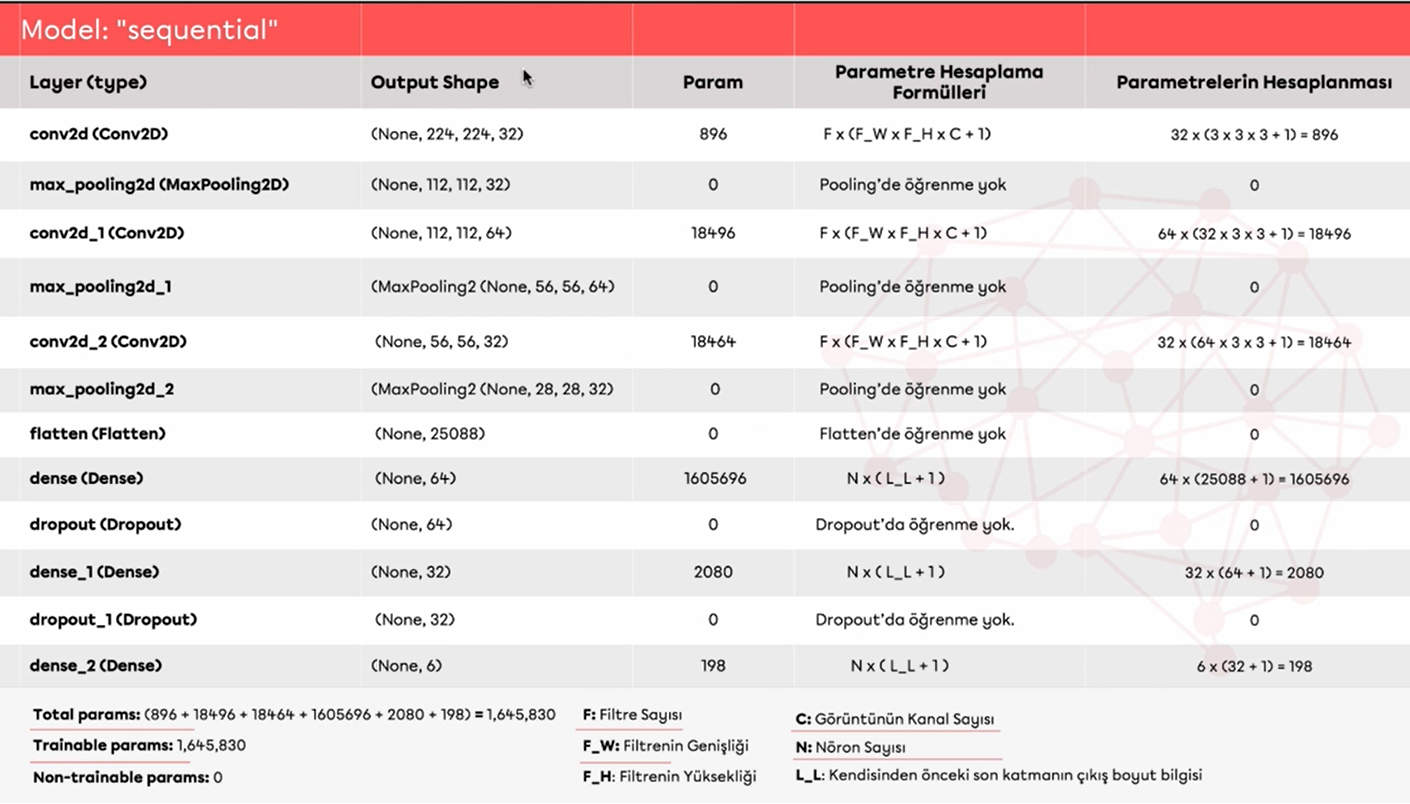

# 4.3 Optimizasyon ve Değerlendirme Metrikleri

In [24]:
model.compile(loss="categorical_crossentropy" , optimizer="adam", metrics=["acc", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
# İkiden fazla sınıf olduğu için loss'umuz categorical_crossentropy. İki sınıf olsaydı binary_crossentropy kullanırdık
# Optimizer dediğimiz loss fonksiyonunu minimize edebilecek optimizasyon yöntemidir. Adam dışında SGD ya da RMSProp kullanılabilir.

In [25]:
# Overfitting'i engellemek için bazı işlemler yapalım
# 1- Early Stopping
callbacks = [EarlyStopping(monitor="val_loss", patience=50 , verbose=1, mode="min") ,
             ModelCheckpoint(filepath="mymodel.h5", monitor="val_loss", mode="min", save_best_only=True, save_weights_only=False, verbose=1)]

# monitor -> modelin gelişimini aşırı öğrenmeyi engellemek adına hangi metrik açısından takip edeceğimizi belirtiyoruz
# patience-> 50 iterasyonda ilerleme olmazsa dur artık diyoruz. Öünkü validasyonda ilerleme yoksa artık ezbere gider
# mode -> model gelişiminin takip edilecebileceği takip parametre değerleri. min, max, automatic gibi değerler alır. min'de izlenen miktarın azalması durduğunda eğitim durur

# Daha sonra ModelCheckpoint ile yakaladığımız en iyi sonucu belirtiyoruz

# 4.4 Modelin Eğitilmesi

In [36]:
history = model.fit(train_generator,
                    epochs=100,
                    validation_data=test_generator,
                    callbacks=callbacks,
                    steps_per_epoch=2276//32,
                    validation_steps=251//32)
# workers -> paralel olarak gruplar oluşturan iş parçacığı sayısı. Gruplar CPU'da paralel olarak hesaplanır ve GPU'ya aktarılır
# step_per_epoch -> bir iterasyonun tamamlandığını ve bir sonraki iterasyoun başladığını bildirmeden önceki toplam adım sayısı...
                    # ...276//32 = 71 her iterasyonda 71 sample ile model eğitimi gerçekleşecek

# Yaklaşık 5 saat sürdü
   # Başlangıçta val_acc = 0.2768
   # Sonda val_acc = 0.7366

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.2347 - loss: 1.7689 - precision_1: 0.3772 - recall_1: 0.0184
Epoch 1: val_loss improved from inf to 1.58320, saving model to mymodel.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 280s 4s/step - acc: 0.2352 - loss: 1.7677 - precision_1: 0.3812 - recall_1: 0.0186 - val_acc: 0.2768 - val_loss: 1.5832 - val_precision_1: 0.7083 - val_recall_1: 0.0759
Epoch 2/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 3:24 3s/step - acc: 0.5312 - loss: 1.3339 - precision_1: 0.8571 - recall_1: 0.1875
Epoch 2: val_loss improved from 1.58320 to 1.57610, saving model to mymodel.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - acc: 0.5312 - loss: 1.3339 - precision_1: 0.8571 - recall_1: 0.1875 - val_acc: 0.3036 - val_loss: 1.5761 - val_precision_1: 0.6111 - val_recall_1: 0.0982
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.3056 - loss: 1.5975 - precision_1: 0.7347 - recall_1: 0.0783
Epoch 3: val_loss improved from 1.57610 to 1.50010, saving model to mymodel.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 321s 4s/step - acc: 0.3057 - loss: 1.5974 - precision_1: 0.7350 - recall_1: 0.0782 - val_acc: 0.3527 - val_loss: 1.5001 - val_precision_1: 0.9286 - val_recall_1: 0.0580
Epoch 4/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 4:55 4s/step - acc: 0.3750 - loss: 1.5458 - precision_1: 1.0000 - recall_1: 0.1250
Epoch 4: val_loss did not improve from 1.50010
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - acc: 0.3750 - loss: 1.5458 - precision_1: 1.0000 - recall_1: 0.1250 - val_acc: 0.3661 - val_loss: 1.5167 - val_precision_1: 0.7391 - val_recall_1: 0.0759
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.3740 - loss: 1.4875 - precision_1: 0.8153 - recall_1: 0.1018
Epoch 5: val_loss improved from 1.50010 to 1.36732, saving model to mymodel.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 324s 4s/step - acc: 0.3740 - loss: 1.4873 - precision_1: 0.8150 - recall_1: 0.1020 - val_acc: 0.4330 - val_loss: 1.3673 - val_precision_1: 0.8367 - val_recall_1: 0.1830
Epoch 6/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 3:15 3s/step - acc: 0.3750 - loss: 1.6609 - precision_1: 0.6000 - recall_1: 0.0938
Epoch 6: val_loss did not improve from 1.36732
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - acc: 0.3750 - loss: 1.6609 - precision_1: 0.6000 - recall_1: 0.0938 - val_acc: 0.4241 - val_loss: 1.3849 - val_precision_1: 0.8511 - val_recall_1: 0.1786
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.4504 - loss: 1.3875 - precision_1: 0.7171 - recall_1: 0.1786
Epoch 7: val_loss did not improve from 1.36732
71/71 ━━━━━━━━━━━━━━━━━━━━ 325s 4s/step - acc: 0.4505 - loss: 1.3874 - precision_1: 0.7173 - recall_1: 0.1788 - val_acc: 0.4420 - val_loss: 1.3859 - val_precision_1: 0.6833 - val_recall_1: 0.1830
Epoch 8/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 3:53 3s/step - acc: 0.5000 - loss: 1.

...

71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - acc: 0.7500 - loss: 0.8448 - precision_1: 0.7727 - recall_1: 0.5312 - val_acc: 0.6830 - val_loss: 0.8287 - val_precision_1: 0.8194 - val_recall_1: 0.5670
Epoch 57/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.6932 - loss: 0.8167 - precision_1: 0.8071 - recall_1: 0.5869
Epoch 57: val_loss did not improve from 0.82873
71/71 ━━━━━━━━━━━━━━━━━━━━ 320s 4s/step - acc: 0.6932 - loss: 0.8168 - precision_1: 0.8072 - recall_1: 0.5869 - val_acc: 0.7009 - val_loss: 0.8356 - val_precision_1: 0.8288 - val_recall_1: 0.5402
Epoch 58/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 3:07 3s/step - acc: 0.8438 - loss: 0.6757 - precision_1: 0.9500 - recall_1: 0.5938
Epoch 58: val_loss did not improve from 0.82873
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 139ms/step - acc: 0.8438 - loss: 0.6757 - precision_1: 0.9500 - recall_1: 0.5938 - val_acc: 0.6920 - val_loss: 0.8368 - val_precision_1: 0.8231 - val_recall_1: 0.5402
Epoch 59/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.7100 - l

71/71 ━━━━━━━━━━━━━━━━━━━━ 291s 4s/step - acc: 0.7216 - loss: 0.8052 - precision_1: 0.8309 - recall_1: 0.6088 - val_acc: 0.6964 - val_loss: 0.8118 - val_precision_1: 0.8163 - val_recall_1: 0.5357
Epoch 62/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 3:09 3s/step - acc: 0.5625 - loss: 1.1723 - precision_1: 0.6087 - recall_1: 0.4375
Epoch 62: val_loss did not improve from 0.81177
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - acc: 0.5625 - loss: 1.1723 - precision_1: 0.6087 - recall_1: 0.4375 - val_acc: 0.7054 - val_loss: 0.8235 - val_precision_1: 0.8456 - val_recall_1: 0.5134
Epoch 63/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.7281 - loss: 0.7609 - precision_1: 0.8363 - recall_1: 0.6163
Epoch 63: val_loss did not improve from 0.81177
71/71 ━━━━━━━━━━━━━━━━━━━━ 320s 5s/step - acc: 0.7280 - loss: 0.7611 - precision_1: 0.8362 - recall_1: 0.6163 - val_acc: 0.6473 - val_loss: 0.8763 - val_precision_1: 0.7922 - val_recall_1: 0.5446
Epoch 64/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 3:07 3s/step - acc: 0.4688 - l

71/71 ━━━━━━━━━━━━━━━━━━━━ 321s 4s/step - acc: 0.7387 - loss: 0.7218 - precision_1: 0.8325 - recall_1: 0.6396 - val_acc: 0.7188 - val_loss: 0.7545 - val_precision_1: 0.8354 - val_recall_1: 0.5893
Epoch 76/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 4:43 4s/step - acc: 0.7812 - loss: 0.7067 - precision_1: 0.9048 - recall_1: 0.5938
Epoch 76: val_loss did not improve from 0.75445
71/71 ━━━━━━━━━━━━━━━━━━━━ 22s 254ms/step - acc: 0.7812 - loss: 0.7067 - precision_1: 0.9048 - recall_1: 0.5938 - val_acc: 0.6920 - val_loss: 0.8119 - val_precision_1: 0.8194 - val_recall_1: 0.5670
Epoch 77/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.7412 - loss: 0.7227 - precision_1: 0.8302 - recall_1: 0.6417
Epoch 77: val_loss did not improve from 0.75445
71/71 ━━━━━━━━━━━━━━━━━━━━ 320s 5s/step - acc: 0.7406 - loss: 0.7242 - precision_1: 0.8299 - recall_1: 0.6409 - val_acc: 0.6384 - val_loss: 0.9824 - val_precision_1: 0.7632 - val_recall_1: 0.5179
Epoch 78/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 3:11 3s/step - acc: 0.6562 - l

71/71 ━━━━━━━━━━━━━━━━━━━━ 310s 4s/step - acc: 0.7792 - loss: 0.6364 - precision_1: 0.8413 - recall_1: 0.6924 - val_acc: 0.7411 - val_loss: 0.7099 - val_precision_1: 0.8613 - val_recall_1: 0.6652
Epoch 94/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 4:24 4s/step - acc: 0.5625 - loss: 1.0318 - precision_1: 0.6207 - recall_1: 0.5625
Epoch 94: val_loss improved from 0.70994 to 0.66946, saving model to mymodel.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 271ms/step - acc: 0.5625 - loss: 1.0318 - precision_1: 0.6207 - recall_1: 0.5625 - val_acc: 0.7500 - val_loss: 0.6695 - val_precision_1: 0.8848 - val_recall_1: 0.6518
Epoch 95/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.7599 - loss: 0.6753 - precision_1: 0.8456 - recall_1: 0.6663
Epoch 95: val_loss did not improve from 0.66946
71/71 ━━━━━━━━━━━━━━━━━━━━ 320s 5s/step - acc: 0.7601 - loss: 0.6749 - precision_1: 0.8456 - recall_1: 0.6665 - val_acc: 0.7054 - val_loss: 0.8297 - val_precision_1: 0.8114 - val_recall_1: 0.6339
Epoch 96/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 3:52 3s/step - acc: 0.8125 - loss: 0.5273 - precision_1: 0.9615 - recall_1: 0.7812
Epoch 96: val_loss did not improve from 0.66946
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - acc: 0.8125 - loss: 0.5273 - precision_1: 0.9615 - recall_1: 0.7812 - val_acc: 0.7098 - val_loss: 0.8147 - val_precision_1: 0.8182 - val_recall_1: 0.6429
Epoch 97/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.7787 - l

# 4.5 Accuracy ve Loss Grafikleri

Text(0.5, 1.0, 'Kayıp Grafiği')

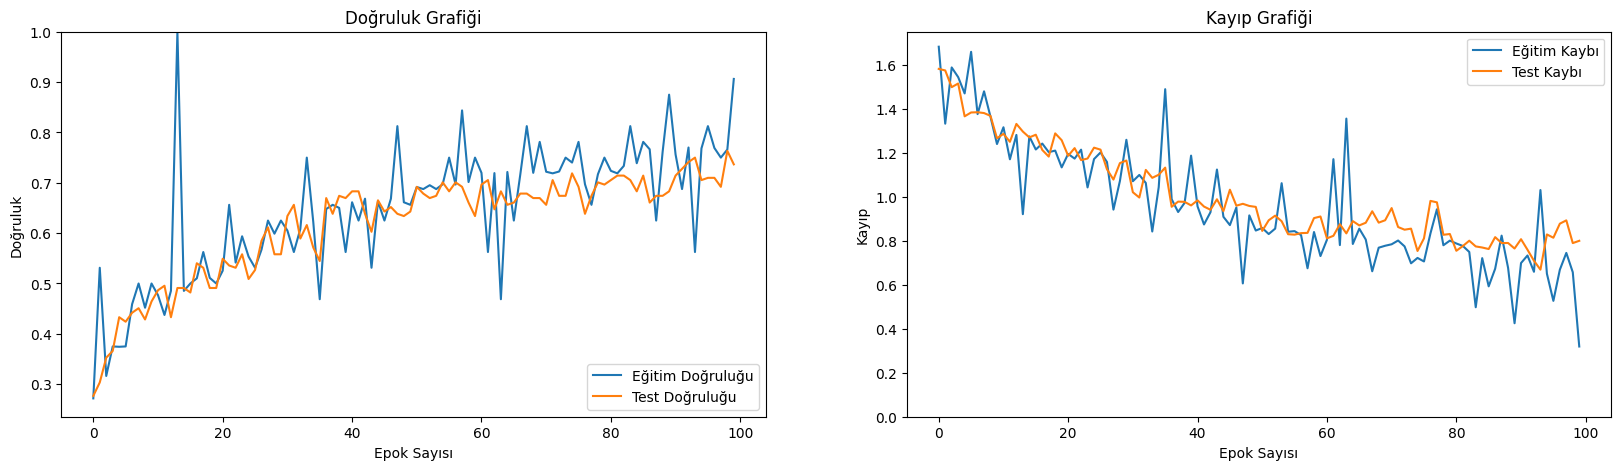

In [37]:
# Accuracy Grafiği
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(history.history["acc"], label="Eğitim Doğruluğu")
plt.plot(history.history["val_acc"], label="Test Doğruluğu")
plt.legend(loc="lower right")
plt.xlabel("Epok Sayısı")
plt.ylabel("Doğruluk")
plt.ylim(min(plt.ylim()), 1)
plt.title("Doğruluk Grafiği")


# Loss Grafiği
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Eğitim Kaybı")
plt.plot(history.history["val_loss"], label="Test Kaybı")
plt.legend(loc="upper right")
plt.xlabel("Epok Sayısı")
plt.ylabel("Kayıp")
plt.ylim(0, max(plt.ylim()))
plt.title("Kayıp Grafiği")

# 5- Değerlendirme

In [38]:
loss, precision, recall, acc = model.evaluate(test_generator , batch_size=32)

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 975ms/step - acc: 0.7050 - loss: 0.9246 - precision_1: 0.7842 - recall_1: 0.6324


In [39]:
# En iyi modelimizin sonuçlarını görelim
print("\nTest Accuracy: %.1f%%" % (100.0 * acc))
print("\nTest Loss: %.1f%%" % (100.0 * loss))
print("\nTest Precision: %.1f%%" % (100.0 * precision))
print("\nTest Recall: %.1f%%" % (100.0 * recall))


Test Accuracy: 65.7%

Test Loss: 78.8%

Test Precision: 73.3%

Test Recall: 81.7%


In [41]:
# Modeli Kullanarak Test Setini Sorup Label'ları Tahmin Ettirelim (Classification Report)
x_test, y_test = next(test_generator)
y_pred = model.predict(test_generator)
y_pred

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step


array([[1.08564238e-03, 3.28958929e-02, 7.89355218e-01, 5.46687981e-03,
        1.07253537e-01, 6.39430508e-02],
       [3.32079738e-01, 1.04942814e-01, 2.52929986e-01, 7.32947811e-02,
        1.29480243e-01, 1.07272476e-01],
       [1.45874419e-05, 9.78882611e-01, 1.11117056e-02, 4.31549764e-04,
        8.82283691e-03, 7.36720511e-04],
       ...,
       [7.92521425e-03, 9.19961706e-02, 5.78696243e-02, 3.98242958e-02,
        1.06030494e-01, 6.96354210e-01],
       [1.28093716e-02, 4.80154677e-06, 1.98558282e-05, 9.85277951e-01,
        1.82603777e-03, 6.19938364e-05],
       [9.89024937e-01, 4.06748848e-03, 5.58771135e-04, 3.80213314e-04,
        5.67620527e-03, 2.92407465e-04]], dtype=float32)

In [43]:
# y_pred = np.argmax(y_pred , axis=1)
# y_test = np.argmax(y_test , axis=1)

# target_names = list(waste_labels.keys())
# print(classification_report(y_test, y_pred, target_names=target_names))


# Test verisinin tamamını almak için list comprehension kullanıyoruz
y_true = np.concatenate([test_generator[i][1] for i in range(len(test_generator))])

# Modelin tüm tahminlerini al
y_pred = model.predict(test_generator)

# One-hot encoded -> Class index
y_true = np.argmax(y_true, axis=1)
y_pred = np.argmax(y_pred, axis=1)

# Sınıf isimleri
target_names = list(waste_labels.keys())

# Classification Report
print(classification_report(y_true, y_pred, target_names=target_names))




# Her bir sınıf için tüm değerleri görüntüleyebiliriz
  # f1-score precision ve recall'un harmonik ortalamasıdır

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
              precision    recall  f1-score   support

   cardboard       0.86      0.75      0.80        40
       glass       0.68      0.76      0.72        50
       metal       0.57      0.76      0.65        41
       paper       0.87      0.93      0.90        59
     plastic       0.70      0.44      0.54        48
       trash       0.69      0.69      0.69        13

    accuracy                           0.73       251
   macro avg       0.73      0.72      0.72       251
weighted avg       0.74      0.73      0.73       251



8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step


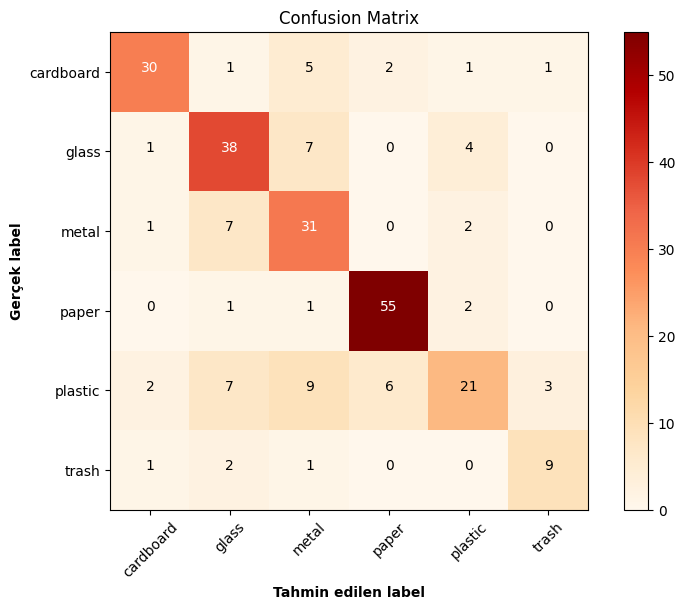

In [47]:
# Son olarak Karmaşılık Matrisi (Confusion Matrix) de Gösterelim


import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report

y_true = np.concatenate([test_generator[i][1] for i in range(len(test_generator))])

y_pred = model.predict(test_generator)

y_true = np.argmax(y_true, axis=1)
y_pred = np.argmax(y_pred, axis=1)

# Confusion Matrix hesaplayalım
cm = confusion_matrix(y_true, y_pred)

# Confusion Matrix'i görselleştirme fonksiyonu
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.OrRd):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Gerçek label', fontweight="bold")
    plt.xlabel('Tahmin edilen label', fontweight="bold")

# Sınıf isimlerini aldık
target_names = list(waste_labels.keys())

# Confusion Matrix'i çizdirdik
plot_confusion_matrix(cm, classes=target_names, title="Confusion Matrix")


# cam olan 1 örnekleme karton demişiz
# cam olan 38 ürüne cam demişiz ...

# 6- Modelin Kullanılması / Test Edilmesi

In [63]:
waste_labels = {0:'cardboard', 1:'glass', 2:'metal', 3:'paper', 4:'plastic', 5:'trash'}

In [64]:
def model_testing(path):
    """
      Görsellerin bulunduğu dizindeki görüntüyü okuyup model aracılığı ile hangi sınıfa ait olduğuna dair tahmin işlemi gerçekleştirilir.

      Parametreler:
      path: Görsellerin bulunduğu dizini ifade eder.

      Return:
      img: Görüntü
      p: Tahmin olasılıkları
      predicted_class: Tahmin sınıfi
    """

    img = image.load_img(path, target_size=(target_size))
    img = image.img_to_array(img, dtype=np.uint8)
    img=np.array(img)/255.0
    p=model.predict(img.reshape(1, 224, 224, 3))
    predicted_class = np.argmax(p[0])

    return img, p, predicted_class

In [67]:
img1, p1, predicted_class1 = model_testing('/content/drive/MyDrive/Garbage classification/metal/metal100.jpg')
img2, p2, predicted_class2 = model_testing('/content/drive/MyDrive/Garbage classification/glass/glass105.jpg')
img3, p3, predicted_class3 = model_testing('/content/drive/MyDrive/Garbage classification/cardboard/cardboard13.jpg')
img4, p4, predicted_class4 = model_testing('/content/drive/MyDrive/Garbage classification/paper/paper106.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


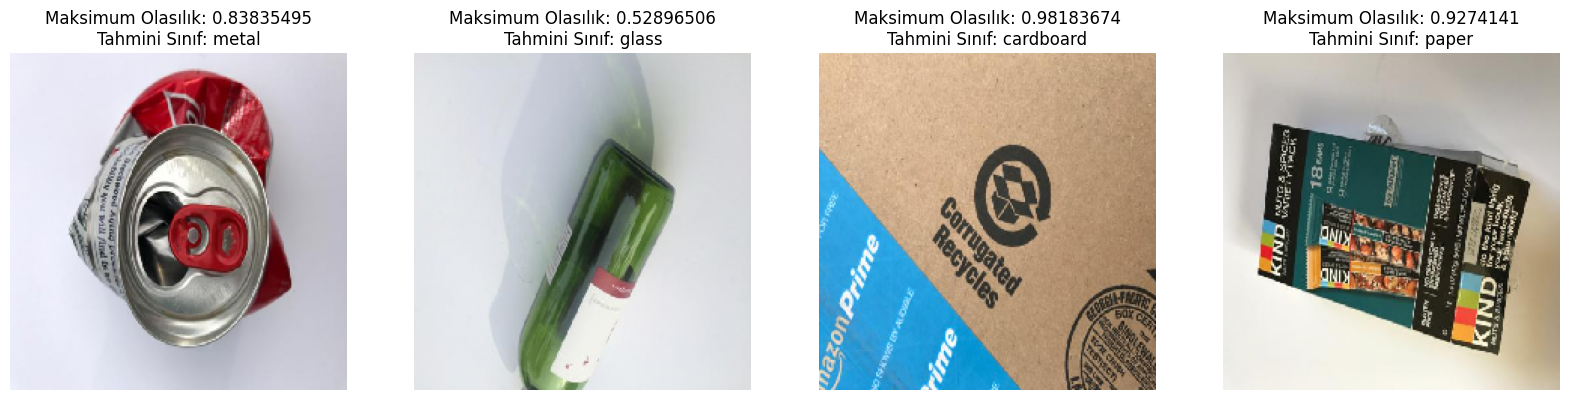

In [68]:
plt.figure(figsize=(20,60))

plt.subplot(141)
plt.axis('off')
plt.imshow(img1.squeeze())
plt.title("Maksimum Olasılık: " + str(np.max(p1[0], axis=-1)) + "\n" +"Tahmini Sınıf: " + str(waste_labels[predicted_class1]))
plt.imshow(imgl);

plt. subplot(142)
plt.axis('off')
plt.imshow(img2.squeeze())
plt.title("Maksimum Olasılık: " + str(np.max(p2[0], axis=-1)) + "\n" +"Tahmini Sınıf: " + str(waste_labels[predicted_class2]))
plt.imshow(img2);

plt.subplot(143)
plt.axis('off')
plt.imshow(img3.squeeze())
plt.title("Maksimum Olasılık: " + str(np.max(p3[0], axis=-1)) + "\n" +"Tahmini Sınıf: " + str(waste_labels[predicted_class3]))
plt.imshow(img3);

plt.subplot(144)
plt.axis('off')
plt.imshow(img4.squeeze())
plt.title("Maksimum Olasılık: " + str(np.max(p4[0], axis=-1)) + "\n" +"Tahmini Sınıf: " + str(waste_labels[predicted_class4]))
plt.imshow(img4);